# Reservoir Distribution Matching via MMD with Gaussian Kernel

A randomly initialized ReLU network serves as the reservoir.
We learn a linear readout $y_i = A x_i + b$ to match a 2D mixture of Gaussians,
minimizing the MMD loss with Gaussian reproducing kernels.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import jit, grad, vmap
import optax
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

print(f"JAX devices: {jax.devices()}")

JAX devices: [CpuDevice(id=0)]


## 1. Configuration

In [2]:
# Reservoir network
INPUT_DIM = 100
WIDTH = 2*64           # W
DEPTH = 4            # D

# Samples
N_RESERVOIR = 2048
N_TARGET = 2048
OUTPUT_DIM = 2

# Training
LEARNING_RATE = 1e-3
LR_END_RATIO = 0.01   # final lr = LEARNING_RATE * LR_END_RATIO (cosine decay)
N_STEPS = 10000
BATCH_SIZE = 512
LOG_EVERY = 500

# Multiple kernel bandwidths for MMD
SIGMAS = [0.1, 0.5, 1.0, 2.0, 5.0]

# Target: mixture of 2 Gaussians in 2D
MIX_MEANS = jnp.array([[-3.0, -3.0],
                        [ 3.0,  3.0]])

MIX_COVS = jnp.array([[[1.0, 0.5],
                        [0.5, 1.0]],
                       [[1.0, -0.3],
                        [-0.3, 0.5]]])

MIX_WEIGHTS = jnp.array([0.4, 0.6])

## 2. Reservoir: frozen ReLU network

In [3]:
# def init_reservoir(key, input_dim, width, depth):
#     """Random ReLU MLP: input_dim -> width -> ... -> width (depth layers).
#     He initialization. Output is the last hidden layer (dim = width)."""
#     params = []
#     dims = [input_dim] + [width] * depth
#     for i in range(len(dims) - 1):
#         key, k1 = jr.split(key)
#         scale = jnp.sqrt(2.0 / dims[i])
#         W = jr.normal(k1, (dims[i], dims[i + 1])) * scale
#         b = jnp.zeros(dims[i + 1])
#         params.append((W, b))
#     return params


# def reservoir_forward(params, x):
#     """Forward pass for a single input vector."""
#     for W, b in params:
#         x = jax.nn.relu(x @ W + b)
#     return x


# reservoir_forward_batch = jit(vmap(reservoir_forward, in_axes=(None, 0)))

## 2. Reservoir: frozen Fourier network

In [4]:
def init_reservoir(key, input_dim, width, depth, omega0=20.0):
    """Random sine network reservoir.
    
    First layer:  weights ~ N(0, omega0^2 / input_dim), bias ~ U(0, 2pi)
    Hidden layers: weights ~ N(0, omega0^2 / width),     bias ~ U(0, 2pi)
    
    omega0 controls the effective frequency — sweep this.
    """
    params = []
    dims = [input_dim] + [width] * depth
    for i in range(len(dims) - 1):
        key, k1, k2 = jr.split(key, 3)
        scale = omega0 / jnp.sqrt(dims[i])
        W = jr.normal(k1, (dims[i], dims[i + 1])) * scale
        b = jr.uniform(k2, (dims[i + 1],), minval=0.0, maxval=2.0 * jnp.pi)
        params.append((W, b))
    return params


def reservoir_forward(params, x):
    """Forward pass with sin activation."""
    for W, b in params:
        x = jnp.sin(x @ W + b)
    return x


reservoir_forward_batch = jit(vmap(reservoir_forward, in_axes=(None, 0)))

## 3. Target: mixture of 2 Gaussians

In [5]:
def sample_mog(key, n, means, covs, weights):
    """Sample from a mixture of Gaussians."""
    K, D = means.shape
    k1, k2 = jr.split(key)
    # component assignments
    assign = jr.choice(k1, K, shape=(n,), p=weights)
    # Cholesky factors
    Ls = jnp.linalg.cholesky(covs)  # (K, D, D)
    # sample standard normals, then transform per component
    eps = jr.normal(k2, (n, D))
    samples = jnp.zeros((n, D))
    for k in range(K):
        mask = (assign == k)[:, None]  # (n, 1)
        component = eps @ Ls[k].T + means[k]
        samples = samples + mask * component
    return samples

## 4. MMD loss with Gaussian kernel

In [6]:
def mmd_squared(P, Q, sigma):
    """Unbiased MMD^2 estimator with Gaussian kernel of bandwidth sigma.
    P: (n, d), Q: (m, d)."""
    n = P.shape[0]
    m = Q.shape[0]
    two_s2 = 2.0 * sigma ** 2

    # pairwise squared distances via expansion
    def sq_dists(X, Y):
        return jnp.sum(X ** 2, axis=1, keepdims=True) - 2.0 * X @ Y.T + jnp.sum(Y ** 2, axis=1)

    K_pp = jnp.exp(-sq_dists(P, P) / two_s2)
    K_qq = jnp.exp(-sq_dists(Q, Q) / two_s2)
    K_pq = jnp.exp(-sq_dists(P, Q) / two_s2)

    # unbiased: exclude diagonals for pp, qq
    t_pp = (jnp.sum(K_pp) - jnp.trace(K_pp)) / (n * (n - 1))
    t_qq = (jnp.sum(K_qq) - jnp.trace(K_qq)) / (m * (m - 1))
    t_pq = jnp.sum(K_pq) / (n * m)

    return t_pp - 2.0 * t_pq + t_qq


def mmd_multi_bandwidth(P, Q, sigmas):
    """Sum of MMD^2 over multiple bandwidths."""
    return sum(mmd_squared(P, Q, s) for s in sigmas)

## 5. Linear readout and loss

In [7]:
def init_readout(key, output_dim, width):
    k1, k2 = jr.split(key)
    A = jr.normal(k1, (output_dim, width)) * 0.01
    b = jnp.zeros(output_dim)
    return {'A': A, 'b': b}


def readout(params, X):
    """y_i = A x_i + b.  X: (n, W) -> (n, output_dim)."""
    return X @ params['A'].T + params['b']


def loss_fn(readout_params, reservoir_samples, target_samples, sigmas):
    Y = readout(readout_params, reservoir_samples)
    return mmd_multi_bandwidth(Y, target_samples, sigmas)

## 6. Generate reservoir and target samples

In [8]:
master_key = jr.PRNGKey(42)
k1, k2, k3, k4 = jr.split(master_key, 4)

# --- Reservoir ---
reservoir_params = init_reservoir(k1, INPUT_DIM, WIDTH, DEPTH)
reservoir_inputs = jr.normal(k2, (N_RESERVOIR, INPUT_DIM))
reservoir_samples = reservoir_forward_batch(reservoir_params, reservoir_inputs)

print(f"Reservoir samples: {reservoir_samples.shape}")
print(f"  mean={float(jnp.mean(reservoir_samples)):.4f}, "
      f"std={float(jnp.std(reservoir_samples)):.4f}, "
      f"frac_active={float(jnp.mean(reservoir_samples > 0)):.3f}")

# --- Target ---
target_samples = sample_mog(k3, N_TARGET, MIX_MEANS, MIX_COVS, MIX_WEIGHTS)
print(f"Target samples:    {target_samples.shape}")

# --- Readout init ---
readout_params = init_readout(k4, OUTPUT_DIM, WIDTH)
print(f"A: {readout_params['A'].shape},  b: {readout_params['b'].shape}")

Reservoir samples: (2048, 128)
  mean=-0.0012, std=0.7081, frac_active=0.499
Target samples:    (2048, 2)
A: (2, 128),  b: (2,)


## 7. Training loop

In [9]:
schedule = optax.cosine_decay_schedule(
    init_value=LEARNING_RATE,
    decay_steps=N_STEPS,
    alpha=LR_END_RATIO,
)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(readout_params)


@jit
def train_step(params, opt_state, res_batch, tgt_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, res_batch, tgt_batch, SIGMAS)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


losses = []
rng = jr.PRNGKey(0)

for step in range(N_STEPS):
    rng, k1, k2 = jr.split(rng, 3)
    idx_r = jr.choice(k1, N_RESERVOIR, shape=(BATCH_SIZE,), replace=False)
    idx_t = jr.choice(k2, N_TARGET,    shape=(BATCH_SIZE,), replace=False)

    readout_params, opt_state, loss = train_step(
        readout_params, opt_state,
        reservoir_samples[idx_r], target_samples[idx_t]
    )
    losses.append(float(loss))

    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        print(f"step {step:5d}  MMD² = {loss:.6f}")

print("Done.")

step     0  MMD² = 4.063933
step   500  MMD² = 0.575555
step  1000  MMD² = 0.351231
step  1500  MMD² = 0.237334
step  2000  MMD² = 0.206046
step  2500  MMD² = 0.165099
step  3000  MMD² = 0.214058
step  3500  MMD² = 0.138821
step  4000  MMD² = 0.158352
step  4500  MMD² = 0.143144
step  5000  MMD² = 0.157900
step  5500  MMD² = 0.120371
step  6000  MMD² = 0.115056
step  6500  MMD² = 0.130922
step  7000  MMD² = 0.149668
step  7500  MMD² = 0.139429
step  8000  MMD² = 0.156395
step  8500  MMD² = 0.124940
step  9000  MMD² = 0.137704
step  9500  MMD² = 0.149328
step  9999  MMD² = 0.147160
Done.


## 8. Visualization

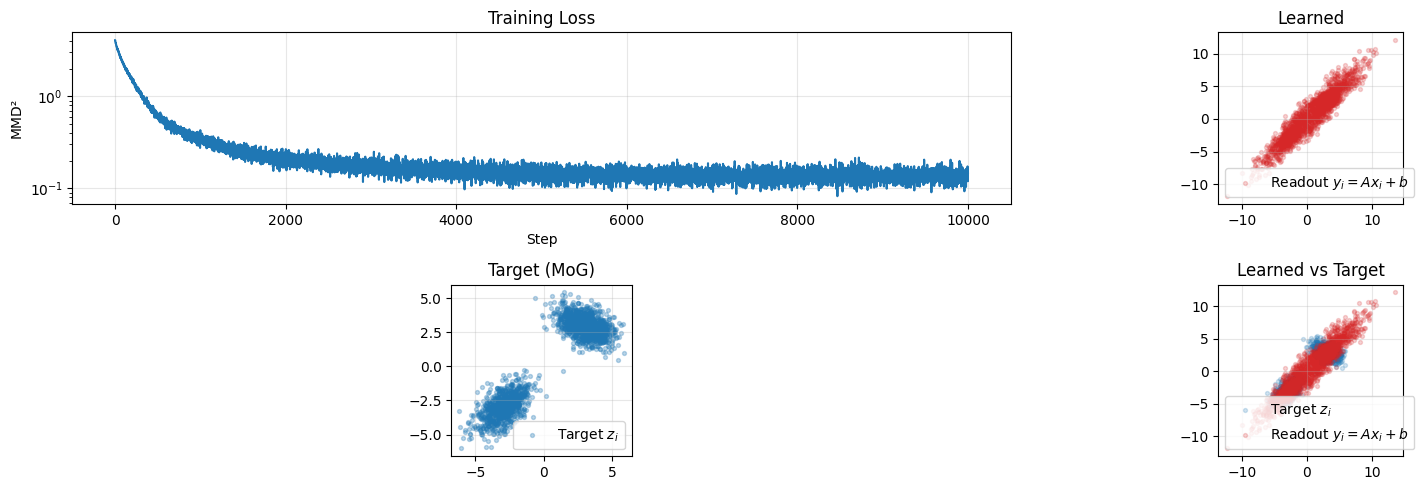

In [10]:
y_final = readout(readout_params, reservoir_samples)  # (N_RESERVOIR, 2)

fig, axes = plt.subplots(2, 2, figsize=(18, 5))

# loss curve
axes[0,0].semilogy(losses)
axes[0,0].set_xlabel('Step'); axes[0,0].set_ylabel('MMD²')
axes[0,0].set_title('Training Loss'); axes[0,0].grid(True, alpha=0.3)

# target
axes[1,0].scatter(target_samples[:, 0], target_samples[:, 1],
                alpha=0.3, s=8, c='tab:blue', label='Target $z_i$')
axes[1,0].set_title('Target (MoG)'); axes[1,0].set_aspect('equal')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# overlay
axes[0,1].scatter(np.array(y_final[:, 0]), np.array(y_final[:, 1]),
                alpha=0.2, s=8, c='tab:red', label='Readout $y_i = Ax_i+b$')
axes[0,1].set_title('Learned'); axes[0,1].set_aspect('equal')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# overlay
axes[1,1].scatter(target_samples[:, 0], target_samples[:, 1],
                alpha=0.2, s=8, c='tab:blue', label='Target $z_i$')
axes[1,1].scatter(np.array(y_final[:, 0]), np.array(y_final[:, 1]),
                alpha=0.2, s=8, c='tab:red', label='Readout $y_i = Ax_i+b$')
axes[1,1].set_title('Learned vs Target'); axes[1,1].set_aspect('equal')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reservoir_mmd_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

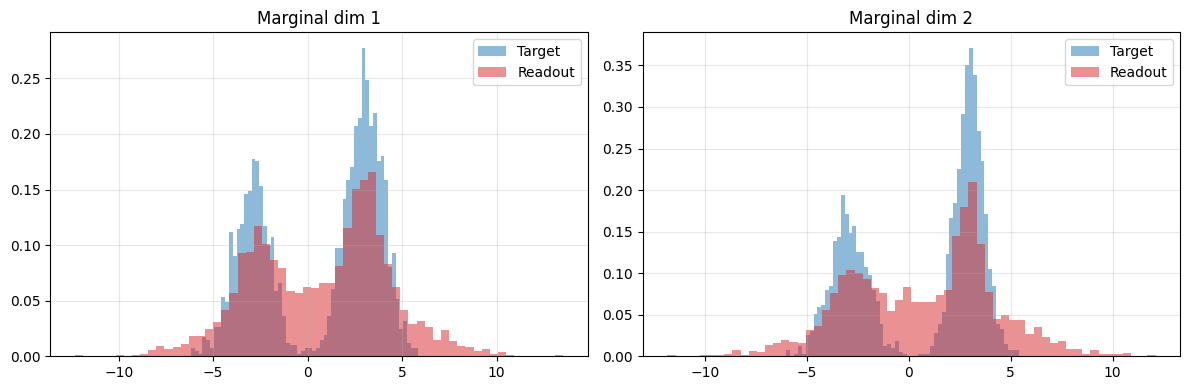

In [11]:
# marginal histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for d, ax in enumerate(axes):
    ax.hist(np.array(target_samples[:, d]), bins=60, density=True,
            alpha=0.5, color='tab:blue', label='Target')
    ax.hist(np.array(y_final[:, d]),        bins=60, density=True,
            alpha=0.5, color='tab:red',  label='Readout')
    ax.set_title(f'Marginal dim {d+1}'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reservoir_mmd_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# moment comparison
z_np = np.array(target_samples)
y_np = np.array(y_final)

print(f"{'':22s} {'Target':>10s} {'Readout':>10s}")
print('-' * 44)
for d in range(OUTPUT_DIM):
    print(f"  Mean   dim {d+1}:      {z_np[:, d].mean():10.4f} {y_np[:, d].mean():10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Std    dim {d+1}:      {z_np[:, d].std():10.4f} {y_np[:, d].std():10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Skew   dim {d+1}:      {skew(z_np[:, d]):10.4f} {skew(y_np[:, d]):10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Kurt   dim {d+1}:      {kurtosis(z_np[:, d]):10.4f} {kurtosis(y_np[:, d]):10.4f}")
print(f"  Corr  (1,2):      {np.corrcoef(z_np.T)[0,1]:10.4f} {np.corrcoef(y_np.T)[0,1]:10.4f}")

## 9. Sweep over reservoir depth and width

In [ ]:
def run_experiment(width, depth, key, n_steps=3000):
    """Full pipeline for one (width, depth) setting. Returns final MMD²."""
    k1, k2, k3 = jr.split(key, 3)

    # reservoir
    rp = init_reservoir(k1, INPUT_DIM, width, depth)
    ri = jr.normal(k2, (N_RESERVOIR, INPUT_DIM))
    rs = reservoir_forward_batch(rp, ri)

    # readout
    ro = init_readout(k3, OUTPUT_DIM, width)
    opt = optax.adam(LEARNING_RATE)
    ost = opt.init(ro)

    @jit
    def step(ro, ost, rb, tb):
        l, g = jax.value_and_grad(loss_fn)(ro, rb, tb, SIGMAS)
        u, ost = opt.update(g, ost, ro)
        ro = optax.apply_updates(ro, u)
        return ro, ost, l

    rng = jr.PRNGKey(7)
    tail_losses = []
    for s in range(n_steps):
        rng, rk1, rk2 = jr.split(rng, 3)
        rb = rs[jr.choice(rk1, N_RESERVOIR, shape=(BATCH_SIZE,), replace=False)]
        tb = target_samples[jr.choice(rk2, N_TARGET, shape=(BATCH_SIZE,), replace=False)]
        ro, ost, l = step(ro, ost, rb, tb)
        if s >= n_steps - 200:
            tail_losses.append(float(l))

    return np.mean(tail_losses)


widths = [16, 32, 64, 128]
depths = [2, 4, 6]
results = {}
sweep_key = jr.PRNGKey(99)

for d in depths:
    for w in widths:
        sweep_key, sk = jr.split(sweep_key)
        fl = run_experiment(w, d, sk)
        results[(w, d)] = fl
        print(f"W={w:4d}  D={d}  =>  MMD² = {fl:.6f}")

print('Sweep done.')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for d in depths:
    vals = [results[(w, d)] for w in widths]
    ax.plot(widths, vals, 'o-', label=f'Depth {d}')
ax.set_xlabel('Reservoir Width')
ax.set_ylabel('Final MMD²')
ax.set_title('Reservoir (Width, Depth) vs Matching Quality')
ax.set_yscale('log')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reservoir_sweep.png', dpi=150, bbox_inches='tight')
plt.show()